In [1]:
#Connecting to Reachy
from reachy_sdk import ReachySDK
# from findIP import get_reachy_ip
# ~/dev/reachy-sdk
reachy = ReachySDK(host='localhost')

#reachy_ip = get_reachy_ip()
# reachy = ReachySDK(host='localhost')# Replace with the actual IP using reachy = ReachySDK(host='192.168.0.42')

In [2]:
#turning on stiff mode for controlling
reachy.turn_on('l_arm')
reachy.turn_on('r_arm')

In [3]:
#goto() Imports

from reachy_sdk.trajectory import goto
from reachy_sdk.trajectory.interpolation import InterpolationMode

In [10]:
#pinching left hand example
pinching_left_hand = {
    reachy.l_arm.l_gripper: -12, #closed
    # reachy.l_arm.l_gripper: 35, #open
}

right_hand_hello = {
    reachy.r_arm.r_shoulder_pitch: -8,
    reachy.r_arm.r_shoulder_roll: -12,
    reachy.r_arm.r_arm_yaw: -43,
    reachy.r_arm.r_elbow_pitch: -129,
    reachy.r_arm.r_forearm_yaw: -62,
    reachy.r_arm.r_wrist_pitch: -6,
    reachy.r_arm.r_wrist_roll: 42,
    reachy.r_arm.r_gripper: 12,
}

r_arm_relax = {
    reachy.r_arm.r_shoulder_pitch: -2,
    reachy.r_arm.r_shoulder_roll: 0,
    reachy.r_arm.r_arm_yaw: -41,
    reachy.r_arm.r_elbow_pitch: -3,
    reachy.r_arm.r_forearm_yaw: -57,
    reachy.r_arm.r_wrist_pitch: 5,
    reachy.r_arm.r_wrist_roll: 16,
    reachy.r_arm.r_gripper: -14,
}

lArm_fistbump = {
    
    reachy.l_arm.l_shoulder_pitch: -2,
    reachy.l_arm.l_shoulder_roll: 4,
    reachy.l_arm.l_arm_yaw: -12,
    reachy.l_arm.l_elbow_pitch: -86,
    reachy.l_arm.l_forearm_yaw: 0,
    reachy.l_arm.l_wrist_pitch: -19,
    reachy.l_arm.l_wrist_roll: 9,
    reachy.l_arm.l_gripper: -13,
}

In [ ]:
#Execute a method
goto(
    goal_positions = lArm_fistbump,
    duration = 6.0,
    interpolation_mode=InterpolationMode.MINIMUM_JERK,
)

In [15]:
#turning off stiff mode
reachy.turn_off_smoothly('l_arm')
reachy.turn_off_smoothly('r_arm')

In [13]:
import time

# recorded_joints = [
#     reachy.r_arm.r_shoulder_pitch,
#     reachy.r_arm.r_shoulder_roll,
#     reachy.r_arm.r_arm_yaw,
#     reachy.r_arm.r_elbow_pitch,
#     reachy.r_arm.r_forearm_yaw,
#     reachy.r_arm.r_wrist_pitch,
#     reachy.r_arm.r_wrist_roll,
# ]
recorded_joints = [
    reachy.l_arm.l_shoulder_pitch,
    reachy.l_arm.l_shoulder_roll,
    reachy.l_arm.l_arm_yaw,
    reachy.l_arm.l_elbow_pitch,
    reachy.l_arm.l_forearm_yaw,
    reachy.l_arm.l_wrist_pitch,
    reachy.l_arm.l_wrist_roll,
]

sampling_frequency = 100  # in Hz
record_duration = 7  # in sec.

trajectories = []

start = time.time()
while (time.time() - start) < record_duration:
    # We here get the present position for all of recorded joints
    current_point = [joint.present_position for joint in recorded_joints]
    # Add this point to the already recorded trajectories
    trajectories.append(current_point)

    time.sleep(1 / sampling_frequency)
print("Trajectory recorded")
print(trajectories)

Trajectory recorded
[[-2.24, 2.77, -12.74, -3.87, 1.93, 5.19, -14.77], [-2.24, 2.77, -12.83, -3.87, 1.93, 5.27, -14.77], [-2.24, 2.85, -12.83, -3.87, 1.93, 5.19, -14.77], [-2.24, 2.85, -12.83, -3.87, 1.93, 5.19, -14.85], [-2.24, 2.85, -12.74, -3.87, 1.93, 5.19, -14.77], [-2.24, 2.85, -12.74, -3.87, 1.93, 5.19, -14.77], [-2.24, 2.94, -12.74, -3.87, 1.93, 5.19, -14.85], [-2.24, 2.94, -12.83, -3.87, 1.93, 5.19, -14.77], [-2.24, 2.94, -12.83, -3.87, 1.93, 5.19, -14.85], [-2.24, 2.94, -12.74, -3.87, 2.02, 5.19, -14.77], [-2.24, 2.94, -12.74, -3.87, 2.02, 5.19, -14.77], [-2.24, 3.03, -12.74, -3.87, 1.93, 5.19, -14.77], [-2.24, 3.03, -12.74, -3.87, 1.93, 5.19, -14.77], [-2.24, 2.94, -12.83, -3.87, 1.93, 5.19, -14.85], [-2.33, 3.03, -12.83, -3.87, 1.93, 5.19, -14.77], [-2.33, 3.03, -12.83, -3.87, 1.93, 5.19, -14.77], [-2.24, 3.03, -12.83, -3.78, 2.02, 5.19, -14.77], [-2.24, 3.03, -12.83, -3.87, 2.02, 5.27, -14.77], [-2.24, 3.03, -12.83, -3.87, 1.93, 5.19, -14.85], [-2.24, 3.03, -12.74, -3.87, 

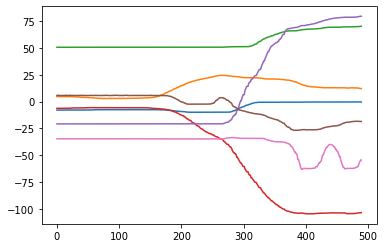

In [29]:
import time

for joints_positions in trajectories:
    for joint, pos in zip(recorded_joints, joints_positions):
        joint.goal_position = pos

    time.sleep(1 / sampling_frequency)

    from matplotlib import pyplot as plt

plt.figure()
plt.plot(trajectories)

In [14]:
from reachy_sdk.trajectory import goto

# Set all used joint stiff
for joint in recorded_joints:
    joint.compliant = False

# Create a dict associating a joint to its first recorded position
first_point = dict(zip(recorded_joints, trajectories[0]))

# Goes to the start of the trajectory in 3s
goto(first_point, duration=3.0)

import time

for joints_positions in trajectories:
    for joint, pos in zip(recorded_joints, joints_positions):
        joint.goal_position = pos

    time.sleep(1 / sampling_frequency)